In [14]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
import seaborn as sns
import matplotlib.pylab as plt

repo_path = Path('~/ukbb-pulmonary-artery/DeepCMR')
assert repo_path.is_dir()
if not str(repo_path.resolve()) in sys.path:
    sys.path.append(str(repo_path.resolve()))

from utils import metrics
import utils.strings as dstr
from utils.strings import str2 

# Loading data

In [15]:
## ================================== EDIT THESE ==================================
## Location of our project folder
PROJ_ROOT = Path('{deepcmr_data_root}/nnUNET/')

## Location of original test nifti files (for generating images)
## (relative to project folder)
original_niftis_path = PROJ_ROOT.joinpath('../OrthancDicomStorage-PracticeNiftis/')

## Location of predicted labels (from nnUNet)
## (relative to project folder)
predicted_niftis_path = PROJ_ROOT.joinpath('../predicted_niftis_nnUNet/Task618_UKBBPulmonaryArtery/test/')

## Where to store results of analysis
## (relative to project folder)
results_path = repo_path.joinpath('results/nnUNet/repeatability_Task618/')
## ================================================================================

Let's start by getting all the `PatientNames` for which we have predicted segmentations, removing the reader `RX` from the name:

In [16]:
InputFiles = [ str2(name).rchop('.nii.gz').rchop(' [R1]').rchop(' [R2]') 
                for name in original_niftis_path.glob('*.nii.gz')
                if not str(name).endswith('_gt.nii.gz') ]
InputFiles = np.unique(InputFiles)

PredictedFiles = [ str2(name).rchop('.nii.gz').rchop(' [R1]').rchop(' [R2]') 
                    for name in predicted_niftis_path.glob('*.nii.gz') ]
PredictedFiles = np.unique(PredictedFiles)

project_prefix = Path(PredictedFiles[0]).name.split('_')[0]

For each subject, we would like to load the manual labels for reader 1 and 2, and the predicted segmentations. We then calculate geometric metrics of performance (i.e., DSC, HD) as well as the area for each reader (i.e, 1, 2, and DL). 

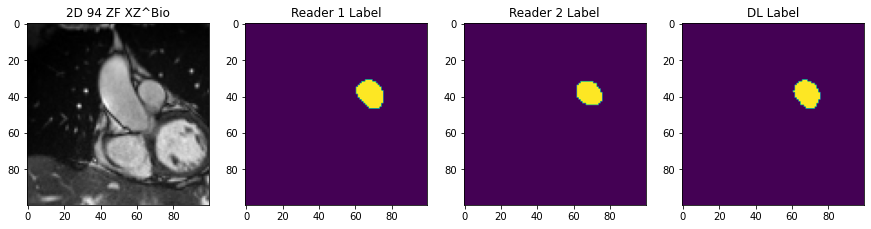

In [17]:
df_metrics = pd.DataFrame({'PatientName':[],'DSC':[], 'HD':[], 'TissueClass':[], 'Phase':[], 'Comparison':[]})
df_areas = {'PatientName':[], 'Reader':[], 'Area':[], 'Phase':[]}

for file in InputFiles:

    PatientName = Path(file).name
    PatientNameShort = dstr.standardize_patient_name(PatientName)
    
    V_nifti_R1 = nib.load(file + ' [R1].nii.gz')
    M_nifti_R1 = nib.load(file + ' [R1]_gt.nii.gz').get_fdata()
    M_nifti_R2 = nib.load(file + ' [R2]_gt.nii.gz').get_fdata()
    M_nifti_DL = nib.load( predicted_niftis_path.joinpath(project_prefix+'_'+PatientNameShort+'[R2].nii.gz') ).get_fdata()
    
    plt.figure(figsize=(15,5))
    plt.subplot(141); plt.imshow(V_nifti_R1.get_fdata()[50:150,50:150,0,0], cmap='gray'); plt.title(PatientName)
    plt.subplot(142); plt.imshow(M_nifti_R1[50:150,50:150,0,0]); plt.title('Reader 1 Label')
    plt.subplot(143); plt.imshow(M_nifti_R2[50:150,50:150,0,0]); plt.title('Reader 2 Label')
    plt.subplot(144); plt.imshow(M_nifti_DL[50:150,50:150,0,0]); plt.title('DL Label')
    plt.show()
    
    voxelspacing = V_nifti_R1.header.get_zooms()[:2]
    for time_frame in range(50):
        df_R1_vs_R2 = metrics.get_geometric_metrics(M_nifti_R1[:,:,0,time_frame], M_nifti_R2[:,:,0,time_frame],
                                                    voxelspacing=voxelspacing, 
                                                    tissue_labels=[1], 
                                                    tissue_label_names=['PA'], 
                                                    phase=time_frame)
        
        df_R1_vs_DL = metrics.get_geometric_metrics(M_nifti_R1[:,:,0,time_frame], M_nifti_DL[:,:,0,time_frame],
                                                    voxelspacing=voxelspacing, 
                                                    tissue_labels=[1], 
                                                    tissue_label_names=['PA'], 
                                                    phase=time_frame)
        
        df_R2_vs_DL = metrics.get_geometric_metrics(M_nifti_R2[:,:,0,time_frame], M_nifti_DL[:,:,0,time_frame],
                                                    voxelspacing=voxelspacing, 
                                                    tissue_labels=[1], 
                                                    tissue_label_names=['PA'], 
                                                    phase=time_frame)

        df_R1_vs_R2['PatientName'] = PatientName
        df_R1_vs_DL['PatientName'] = PatientName
        df_R2_vs_DL['PatientName'] = PatientName
        df_R1_vs_R2['Comparison'] = 'R1_vs_R2'
        df_R1_vs_DL['Comparison'] = 'R1_vs_DL'
        df_R2_vs_DL['Comparison'] = 'R2_vs_DL'
        
        df_metrics = pd.concat((df_metrics, df_R1_vs_R2, df_R1_vs_DL, df_R2_vs_DL))
        
        # area metrics
        area_R1 = metrics.get_area_cm2(M_nifti_R1[:,:,0,time_frame], pixel_spacing_mm=voxelspacing)
        area_R2 = metrics.get_area_cm2(M_nifti_R2[:,:,0,time_frame], pixel_spacing_mm=voxelspacing)
        area_DL = metrics.get_area_cm2(M_nifti_DL[:,:,0,time_frame], pixel_spacing_mm=voxelspacing)
        
        for reader, area in zip([1,2,'DL'],[area_R1, area_R2, area_DL]):
            df_areas['PatientName'] += [PatientName]
            df_areas['Reader'] += [reader]
            df_areas['Area'] += [area]
            df_areas['Phase'] += [time_frame]

df_areas = pd.DataFrame(df_areas)        

Let's take a look at the mean ± std of the geometric metrics:

In [7]:
df_metrics.groupby('Comparison').mean(), df_metrics.groupby('Comparison').std()

(                 DSC        HD  Phase
 Comparison                           
 R1_vs_DL    0.956754  2.357488   24.5
 R1_vs_R2    0.953876  2.235240   24.5
 R2_vs_DL    0.949204  2.470781   24.5,
                  DSC        HD      Phase
 Comparison                               
 R1_vs_DL    0.030283  1.232348  14.433816
 R1_vs_R2    0.026652  1.190804  14.433816
 R2_vs_DL    0.032428  1.418208  14.433816)

### Distensibility bias

Let's calculate the distensibility bias between readers:

In [ ]:
df_bias = {'PatientName':[], 'bias_R1_vs_R2':[], 'bias_R1_vs_DL':[], 'bias_R2_vs_DL':[]}

for PatientName in sorted(df_areas.PatientName.unique()):
    df_areas_Patient = df_areas[df_areas.PatientName==PatientName]
    
    area_max = df_areas_Patient.groupby('Reader').max()['Area']
    area_min = df_areas_Patient.groupby('Reader').min()['Area']
    distensibility = 100*((area_max - area_min)/area_min)
    d_R1, d_R2, d_DL = distensibility
    
    bias_R1_vs_R2 = d_R2 - d_R1
    bias_R1_vs_DL = d_DL - d_R1
    bias_R2_vs_DL = d_DL - d_R2
    
    sns.lineplot(data=df_areas_Patient, x='Phase',y='Area',hue='Reader')
    plt.ylabel('Area (cm)')
    plt.xlabel('Time Frame')
    plt.title('%s \n Bias R2-R1:%.2f,  DL-R1:%.2f,  DL-R2:%.2f bias_r1_vs_r2'%(PatientName,bias_R1_vs_R2,bias_R1_vs_DL,bias_R2_vs_DL))
    plt.show()
    
    df_bias['PatientName'] += [PatientName]
    df_bias['bias_R1_vs_R2'] += [bias_R1_vs_R2]
    df_bias['bias_R1_vs_DL'] += [bias_R1_vs_DL]
    df_bias['bias_R2_vs_DL'] += [bias_R2_vs_DL]
    
    
df_bias = pd.DataFrame(df_bias)    
    

In [9]:
df_bias.mean(), df_bias.std()

(bias_R1_vs_R2   -0.068309
 bias_R1_vs_DL   -2.040270
 bias_R2_vs_DL   -1.971961
 dtype: float64,
 bias_R1_vs_R2    7.834745
 bias_R1_vs_DL    8.497813
 bias_R2_vs_DL    9.137244
 dtype: float64)

In [10]:
df_bias.drop(columns='PatientName').abs().mean(),df_bias.drop(columns='PatientName').abs().std()

(bias_R1_vs_R2    5.778608
 bias_R1_vs_DL    6.106731
 bias_R2_vs_DL    6.666433
 dtype: float64,
 bias_R1_vs_R2    5.224942
 bias_R1_vs_DL    6.196222
 bias_R2_vs_DL    6.487811
 dtype: float64)

In [13]:
results_path.mkdir(parents=True, exist_ok=True)
df_bias.to_csv( results_path.joinpath('df_bias.csv.gz'),
                index=False, 
                compression='gzip')
df_metrics.to_csv( results_path.joinpath('df_metrics.csv.gz'),
                index=False, 
                compression='gzip')
df_areas.to_csv( results_path.joinpath('df_areas.csv.gz'),
                index=False, 
                compression='gzip')